In [1]:
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
import matplotlib.pyplot as plt
import os
import arviz as az

from scipy.stats import probplot

## Pre-requisities
- Make sure you have the proper libraries installed
- PyMC uses ```g++``` as its backend. If you don't have it, install it. This is a [useful video](https://www.youtube.com/watch?v=a1ctDgH9rO8) on how to install it on Windows 11. Restart computer after installing.
- Dataset can be found on Kaggle [here](https://www.kaggle.com/datasets/radheshyamkollipara/bank-customer-churn?resource=download). Here is a brief description of all the features present in the data:

    - ```RowNumber```—corresponds to the record (row) number and has no effect on the output.
    - ```CustomerId```—contains random values and has no effect on customer leaving the bank.
    - ```Surname```—the surname of a customer has no impact on their decision to leave the bank.
    - ```CreditScore```—can have an effect on customer churn, since a customer with a higher credit score is less likely to leave the bank.
    - ```Geography```—a customer’s location can affect their decision to leave the bank.
    - ```Gender```—it’s interesting to explore whether gender plays a role in a customer leaving the bank.
    - ```Age```—this is certainly relevant, since older customers are less likely to leave their bank than younger ones.
    - ```Tenure```—refers to the number of years that the customer has been a client of the bank. Normally, older clients are more loyal and less likely to leave a bank.
    - ```Balance```—also a very good indicator of customer churn, as people with a higher balance in their accounts are less likely to leave the bank compared to those with lower balances.
    - ```NumOfProducts```—refers to the number of products that a customer has purchased through the bank.
    - ```HasCrCard```—denotes whether or not a customer has a credit card. This column is also relevant, since people with a credit card are less likely to leave the bank.
    - ```IsActiveMember```—active customers are less likely to leave the bank.
    - ```EstimatedSalary```—as with balance, people with lower salaries are more likely to leave the bank compared to those with higher salaries.
    - ```Exited```—whether or not the customer left the bank (also our ```Y``` or target variable)
    - ```Complain```—customer has complaint or not.
    - ```Satisfaction``` Score—Score provided by the customer for their complaint resolution.
    - ```Card Type```—type of card hold by the customer.
    - ```Points``` Earned—the points earned by the customer for using credit card.

In [2]:
data_dir =  r"C:\Users\jluo1\Documents\repos\bayesian_statistics\data"
churn_data = pd.read_csv(os.path.join(data_dir, "Customer-Churn-Records.csv"))
churn_data.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1,1,5,DIAMOND,484
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0,0,2,SILVER,206
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1,1,2,DIAMOND,282
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0,0,3,GOLD,251
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0,0,3,GOLD,342


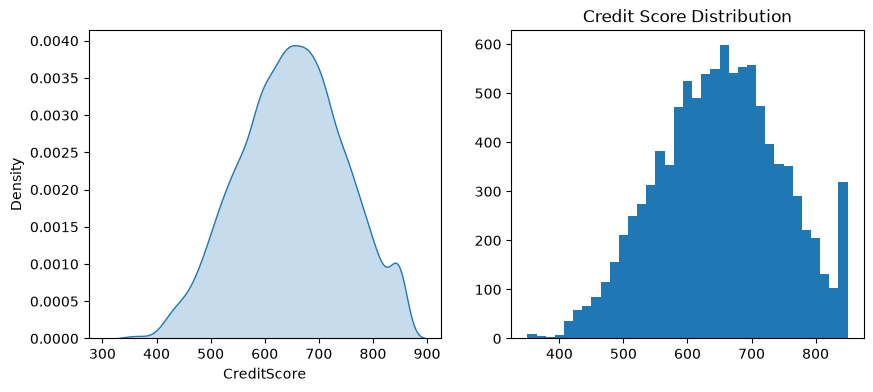

In [3]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = [10,4])

sns.kdeplot(data = churn_data,
            x = "CreditScore",
            fill = True,
            ax = axs[0])
axs[1].hist(x = churn_data.CreditScore, bins = 35)
plt.title("Credit Score Distribution")
plt.show()

## Model 1

Suppose I wanted to model the standard deviation of credit score. Looking this distribution it looks normal(ish), so an obvious estimate would be the sample mean/std. What if we use a Bayesian approach?

Lets say credit score ~ $\mathcal{N}(650, \sigma)$ and we want to estimate $\sigma$. We need to impose a prior on $\sigma$. Lets say its also normally distributed but with a really high variance. From background knowledge, credit score can range from 300-850, so lets say $\sigma$ has mean 175 with some really high variance. So our model is

$$ \sigma \sim \mathcal{N}(175, 20) $$
$$ CreditScore \sim \mathcal{N}(650, \sigma) $$

You could also write this as 

$$ \mathcal{X} \sim \mathcal{N}(175, 20) $$
$$ \mathcal{Y} | \mathcal{X} \sim \mathcal{N}(650, \mathcal{X}) $$

where $\mathcal{X}$ and $\mathcal{Y}$ are sigma and the credit score respectively

Thus we can write:

$$ p(\mathcal{X} | \mathcal{Y}) = \frac{p(\mathcal{Y} | \mathcal{X})p(\mathcal{X})}{p(\mathcal{Y})} $$

or

$$ p(\mathcal{X} | \mathcal{Y}) \propto p(\mathcal{Y} | \mathcal{X})p(\mathcal{X}) $$

The conditional pdf on the left hand side treats $\mathcal{Y}$ (the data) and $\mathcal{X}$ as a random variable, representing the posterior distribution of the parameter we want to estimate (which is $\sigma$). The conditional pdf on the right hand side treats  $\mathcal{X}$ (the parameters) as fixed and $\mathcal{Y}$ (the data) as a random variable, representing the likelihood (i.e given that we have some belief $\sigma$ follows $\mathcal{N}(175, 20)$, what must the data look like?).  When finding the MAP (Maximum A Posteriori), we are trying to find the maximize the posterior probability ($ p(\mathcal{X} | \mathcal{Y})$), whereas MLE (Maximum Likelihood Estimation) tries to estimate the likelihood ($p(\mathcal{Y} | \mathcal{X})$

In [4]:
with pm.Model() as creditScoreModel:
    # prior
    sigma = pm.Normal('sigma', mu = 175, sigma = 20) # sigma is the name of the object in this creditScoreModel

    # likelihood
    observed = pm.Normal('observed', mu = 650, sigma = sigma, observed = churn_data.CreditScore)

In [5]:
n_samples = 500
with creditScoreModel:
    # Sampling from prior distribution before seeing any observed data
    prior_idata = pm.sample_prior_predictive(n_samples) # idata just means inference data
        

Sampling: [observed, sigma]


In [6]:
with creditScoreModel:
    # compute the posterior
    posterior_idata = pm.sample(n_samples, njobs = 4)

NUTS[nutpie]: [sigma]


Output()

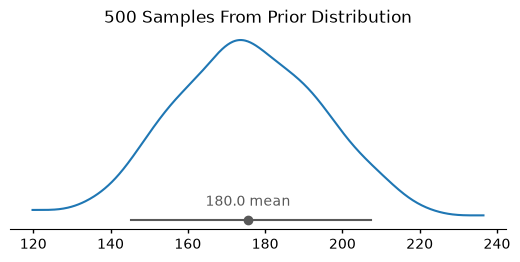

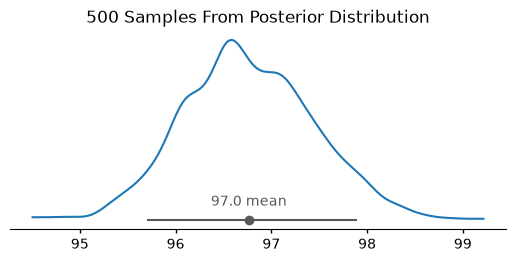

In [7]:
az.plot_dist(prior_idata, group = "prior")
plt.title(f"{n_samples} Samples From Prior Distribution")
az.plot_dist(posterior_idata, group = "posterior")
plt.title(f"{n_samples} Samples From Posterior Distribution")
plt.show()

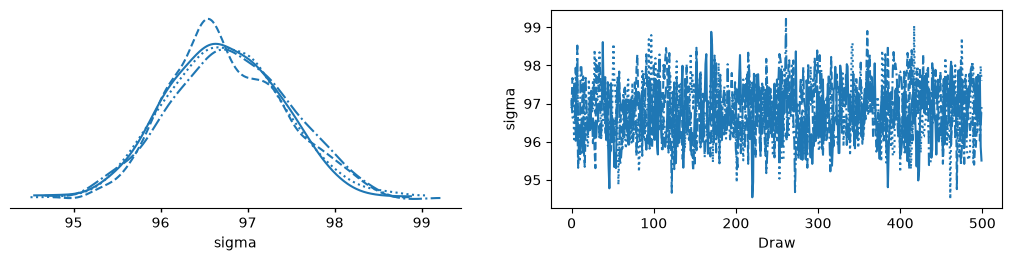

In [8]:
az.plot_trace_dist(posterior_idata, group="posterior")

In [9]:
# Compute the maximum a posteriori
with creditScoreModel:
    map_est = pm.find_MAP()

Output()

In [10]:
sample_std = np.std(churn_data.CreditScore)
sample_mean = np.mean(churn_data.CreditScore), "\n"
print(f"MLE says standard deviation is {sample_std}, while the MAP says it is {map_est['sigma']}")

MLE says standard deviation is 96.64846595037089, while the MAP says it is 96.741508140664


## Model 2

Lets say now I didn't know either the mean and variance for some reason, but I knew that population credit scores tend to be left-skewed. The Weibull distribution is left-skewed if the $\beta$ parameter is above 3.6. Another model could look like this

$$ \alpha \sim \mathcal{N}(2.5, 40) $$
$$ \beta \sim \mathcal{N}(2.5, 40) $$
$$ CreditScore \sim Weibull(\alpha, \beta) $$

Again we can write this as 

$$ \mathcal{X} \sim \mathcal{N}(2.5, 40) $$
$$ \mathcal{Y} \sim \mathcal{N}(2.5, 40) $$
$$ \mathcal{Z} | \mathcal{Y}, \mathcal{X} \sim Weibull(\alpha, \beta) $$

Which also means

$$ p(\mathcal{X}, \mathcal{Y}| \mathcal{Z}) \propto p(\mathcal{Z} | \mathcal{X}, \mathcal{Y})p(\mathcal{X}) p(\mathcal{Y})$$

In [11]:
with pm.Model() as creditScoreModel2:
    alpha = pm.Normal("alpha", mu = 2.5, sigma = 40)
    beta = pm.Normal("beta", mu = 2.5, sigma = 40)
    observed = pm.Weibull("observed", alpha = alpha, beta = beta, observed=churn_data.CreditScore)

    prior_idata = pm.sample_prior_predictive(n_samples)
    posterior_idata = pm.sample(n_samples, njobs = 4)

Sampling: [alpha, beta, observed]
NUTS[nutpie]: [alpha, beta]


Output()

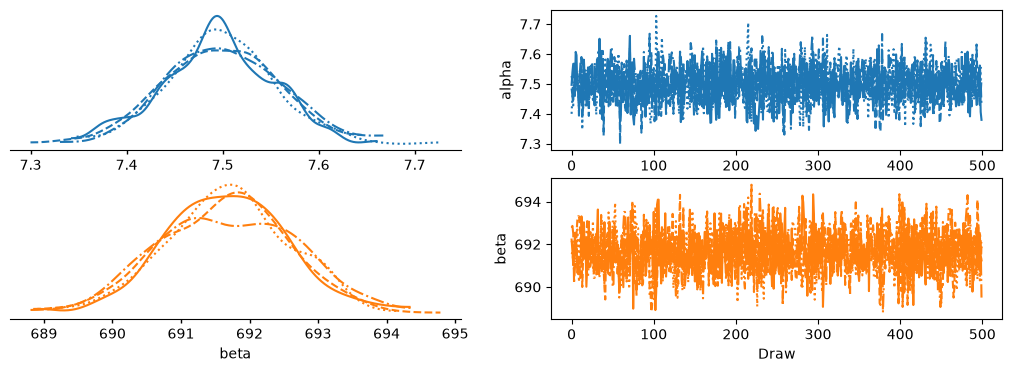

In [12]:
az.plot_trace_dist(posterior_idata)

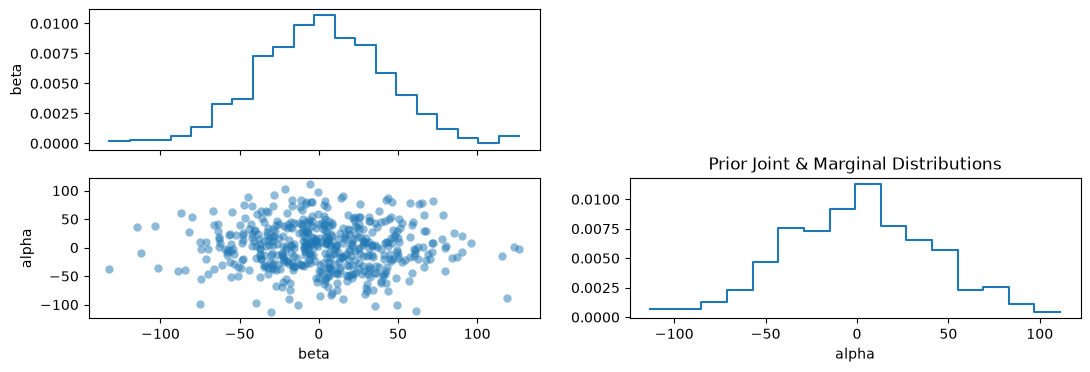

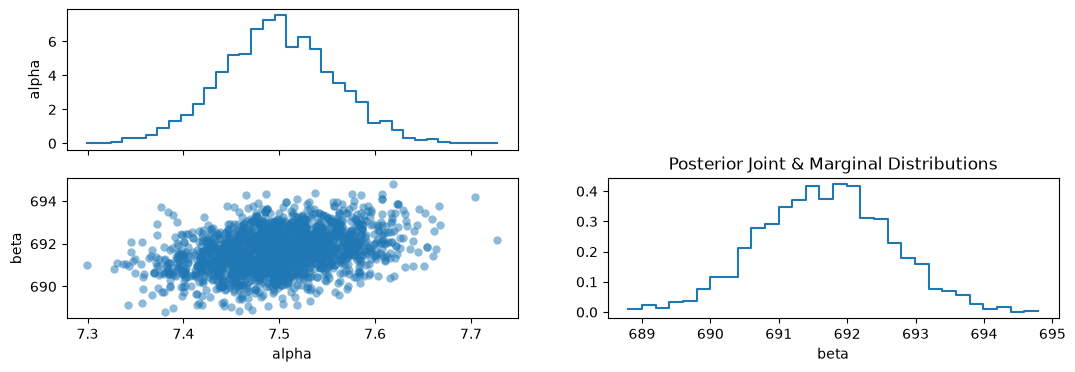

In [13]:
az.plot_pair(prior_idata,
             marginal_kind="hist", group="prior")
plt.title("Prior Joint & Marginal Distributions")
az.plot_pair(posterior_idata,
             marginal_kind="hist", group="posterior")
plt.title("Posterior Joint & Marginal Distributions")
plt.show()


In [14]:
with creditScoreModel2:
    map_est = pm.find_MAP()

Output()

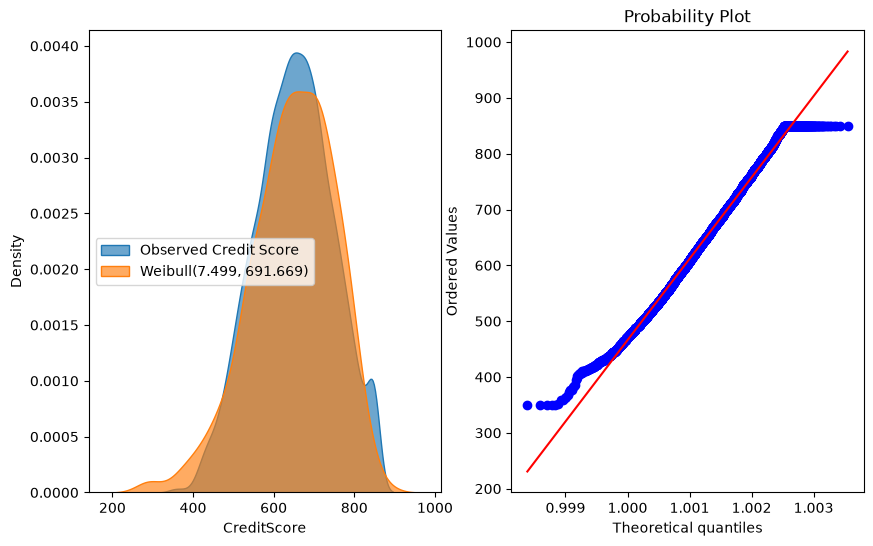

In [15]:
estimated_weibull = np.random.weibull(a = map_est['alpha'], size = 1000) * map_est['beta']

_, axs = plt.subplots(1, 2, figsize = (10,6))

sns.kdeplot(data = churn_data.CreditScore, fill = True, alpha = 0.65, ax = axs[0])
sns.kdeplot(data = estimated_weibull, fill = True, alpha = 0.65, ax = axs[0])
axs[0].legend(['Observed Credit Score', f'Weibull({np.round(map_est['alpha'], 3)}, {np.round(map_est['beta'], 3)})'])

probplot(x = churn_data.CreditScore, dist = 'exponweib', sparams=(map_est['alpha'], map_est['beta']), plot = axs[1])
plt.show()